# 4. Кластеризація k-Means

**k-Means** розбиває дані на k кластерів, мінімізуючи суму квадратів відстаней до центроїдів.

Кластеризація виконується на **3 парах атрибутів** з найвищим lift (визначених Apriori).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, time
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('data_processed.csv')
with open('top4_pairs.json') as f:
    pairs = json.load(f)
print(f"Дані: {df.shape}")
print(f"Пари для кластеризації: {pairs}")

Дані: (26056, 5)
Пари для кластеризації: [['education-num', 'occupation'], ['hours-per-week', 'occupation'], ['age', 'hours-per-week']]


## 4.1 Підбір k для кожної пари

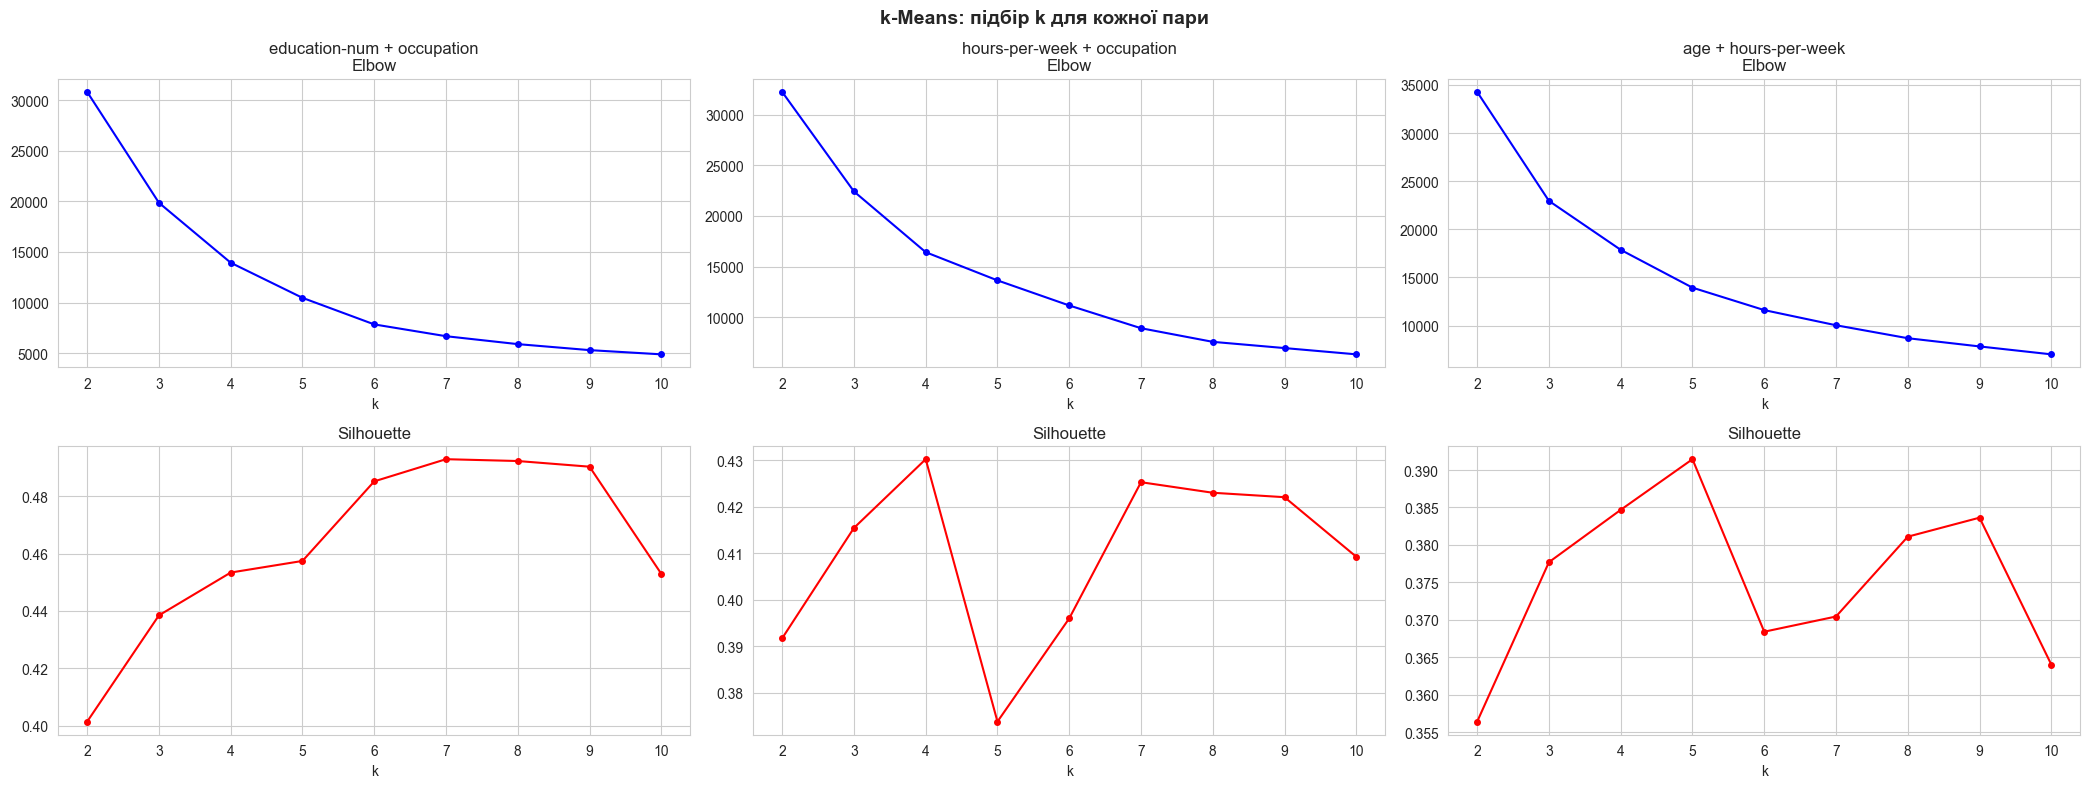

education-num + occupation: найкращий k = 7
hours-per-week + occupation: найкращий k = 4
age + hours-per-week: найкращий k = 5


In [2]:
K_range = range(2, 11)
best_k = {}
N = len(pairs)

fig, axes = plt.subplots(2, N, figsize=(7*N, 8))

for j, pair in enumerate(pairs):
    X = StandardScaler().fit_transform(df[pair].values)
    inertias, sils = [], []
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(X, labels))
    
    axes[0, j].plot(list(K_range), inertias, 'bo-', markersize=4)
    axes[0, j].set_title(f'{pair[0]} + {pair[1]}\nElbow')
    axes[0, j].set_xlabel('k')
    
    axes[1, j].plot(list(K_range), sils, 'ro-', markersize=4)
    axes[1, j].set_title('Silhouette')
    axes[1, j].set_xlabel('k')
    
    best_k[j] = list(K_range)[np.argmax(sils)]

plt.suptitle('k-Means: підбір k для кожної пари', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for j, pair in enumerate(pairs):
    print(f"{pair[0]} + {pair[1]}: найкращий k = {best_k[j]}")

## 4.2 Кластеризація та 2D-візуалізація

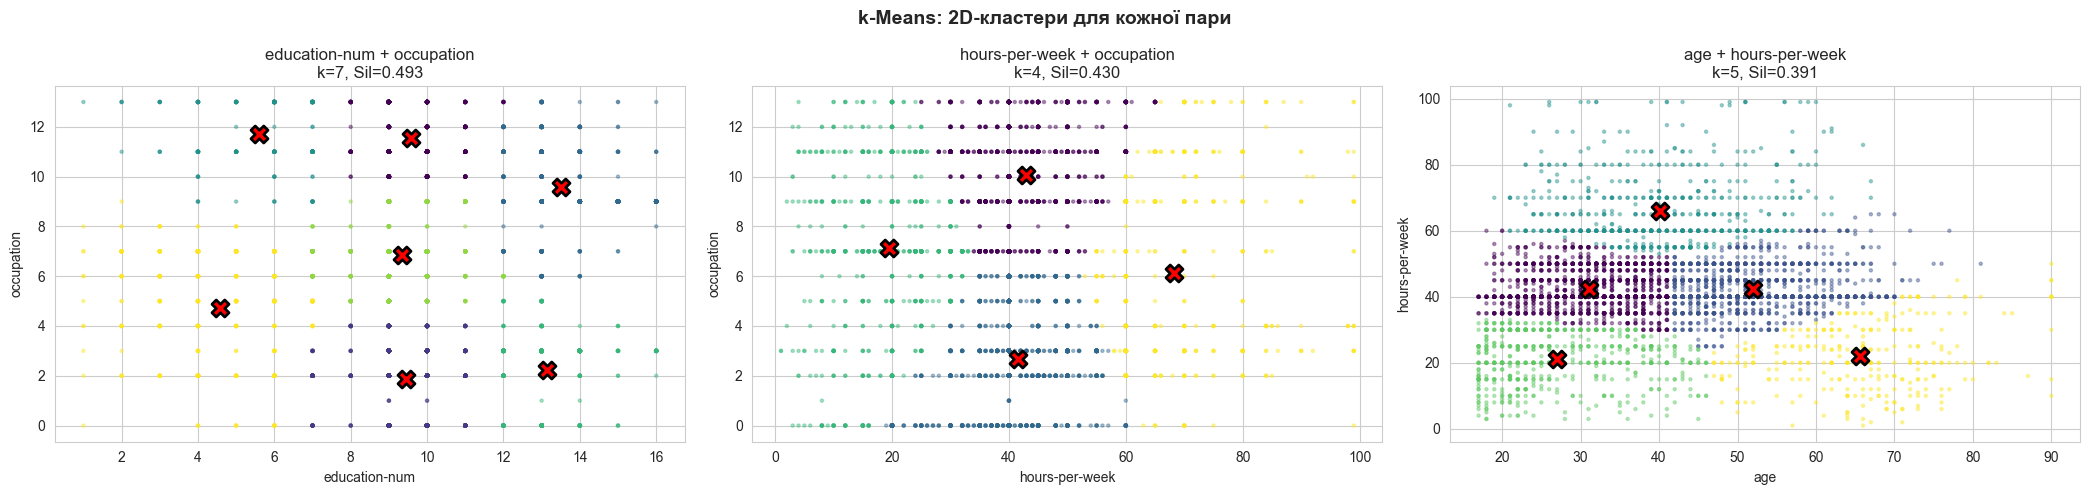

,algorithm,pair,k,silhouette,davies_bouldin,calinski_harabasz,time
0,k-Means,education-num + occupation,7,0.492895,0.650544,29591.869700,0.098449
1,k-Means,hours-per-week + occupation,4,0.430224,0.824971,18857.320697,0.070253
2,k-Means,age + hours-per-week,5,0.391447,0.824173,17833.665115,0.118118


In [3]:
all_results = []

fig, axes = plt.subplots(1, N, figsize=(7*N, 5))

for j, pair in enumerate(pairs):
    X_raw = df[pair].values
    X = StandardScaler().fit_transform(X_raw)
    k = best_k[j]
    
    start = time.time()
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    elapsed = time.time() - start
    
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    
    all_results.append({'algorithm': 'k-Means', 'pair': f'{pair[0]} + {pair[1]}',
                        'k': int(k), 'silhouette': sil, 'davies_bouldin': db,
                        'calinski_harabasz': ch, 'time': elapsed})
    
    idx = np.random.RandomState(42).choice(len(X_raw), min(5000, len(X_raw)), replace=False)
    scatter = axes[j].scatter(X_raw[idx, 0], X_raw[idx, 1], c=labels[idx],
                              cmap='viridis', alpha=0.4, s=5)
    scaler = StandardScaler().fit(X_raw)
    centers = scaler.inverse_transform(km.cluster_centers_)
    axes[j].scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=150,
                    edgecolors='black', linewidths=2, zorder=5)
    axes[j].set_xlabel(pair[0])
    axes[j].set_ylabel(pair[1])
    axes[j].set_title(f'{pair[0]} + {pair[1]}\nk={k}, Sil={sil:.3f}')

plt.suptitle('k-Means: 2D-кластери для кожної пари', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(all_results)
results_df.to_csv('results_kmeans.csv', index=False)
results_df

## 4.3 Результати

In [4]:
print("k-Means — результати по парах:")
print("="*80)
print(f"{'Пара':<35} {'k':>3} {'Silhouette':>12} {'Davies-Bouldin':>15} {'Calinski-H':>12}")
print("-"*80)
for _, r in results_df.iterrows():
    print(f"{r['pair']:<35} {int(r['k']):>3} {r['silhouette']:>12.4f} {r['davies_bouldin']:>15.4f} {r['calinski_harabasz']:>12.1f}")
print("="*80)

k-Means — результати по парах:
Пара                                  k   Silhouette  Davies-Bouldin   Calinski-H
--------------------------------------------------------------------------------
education-num + occupation            7       0.4929          0.6505      29591.9
hours-per-week + occupation           4       0.4302          0.8250      18857.3
age + hours-per-week                  5       0.3914          0.8242      17833.7
